In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt

## Задача 1. 

Поиграемся с датасетом про диабет (он совсем легкий). 

In [2]:
data = pd.read_csv('Diabetes Binary Classification.csv')
data.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable (0 or 1)
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Целевая переменная тут явно обозначена как Class variable (очевидно, есть у человека диабет или нет)

In [3]:
data.info() #пропущенных значений нет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Number of times pregnant                                                  768 non-null    int64  
 1   Plasma glucose concentration a 2 hours in an oral glucose tolerance test  768 non-null    int64  
 2   Diastolic blood pressure (mm Hg)                                          768 non-null    int64  
 3   Triceps skin fold thickness (mm)                                          768 non-null    int64  
 4   2-Hour serum insulin (mu U/ml)                                            768 non-null    int64  
 5   Body mass index (weight in kg/(height in m)^2)                            768 non-null    float64
 6   Diabetes pedigree function                                         

<Axes: >

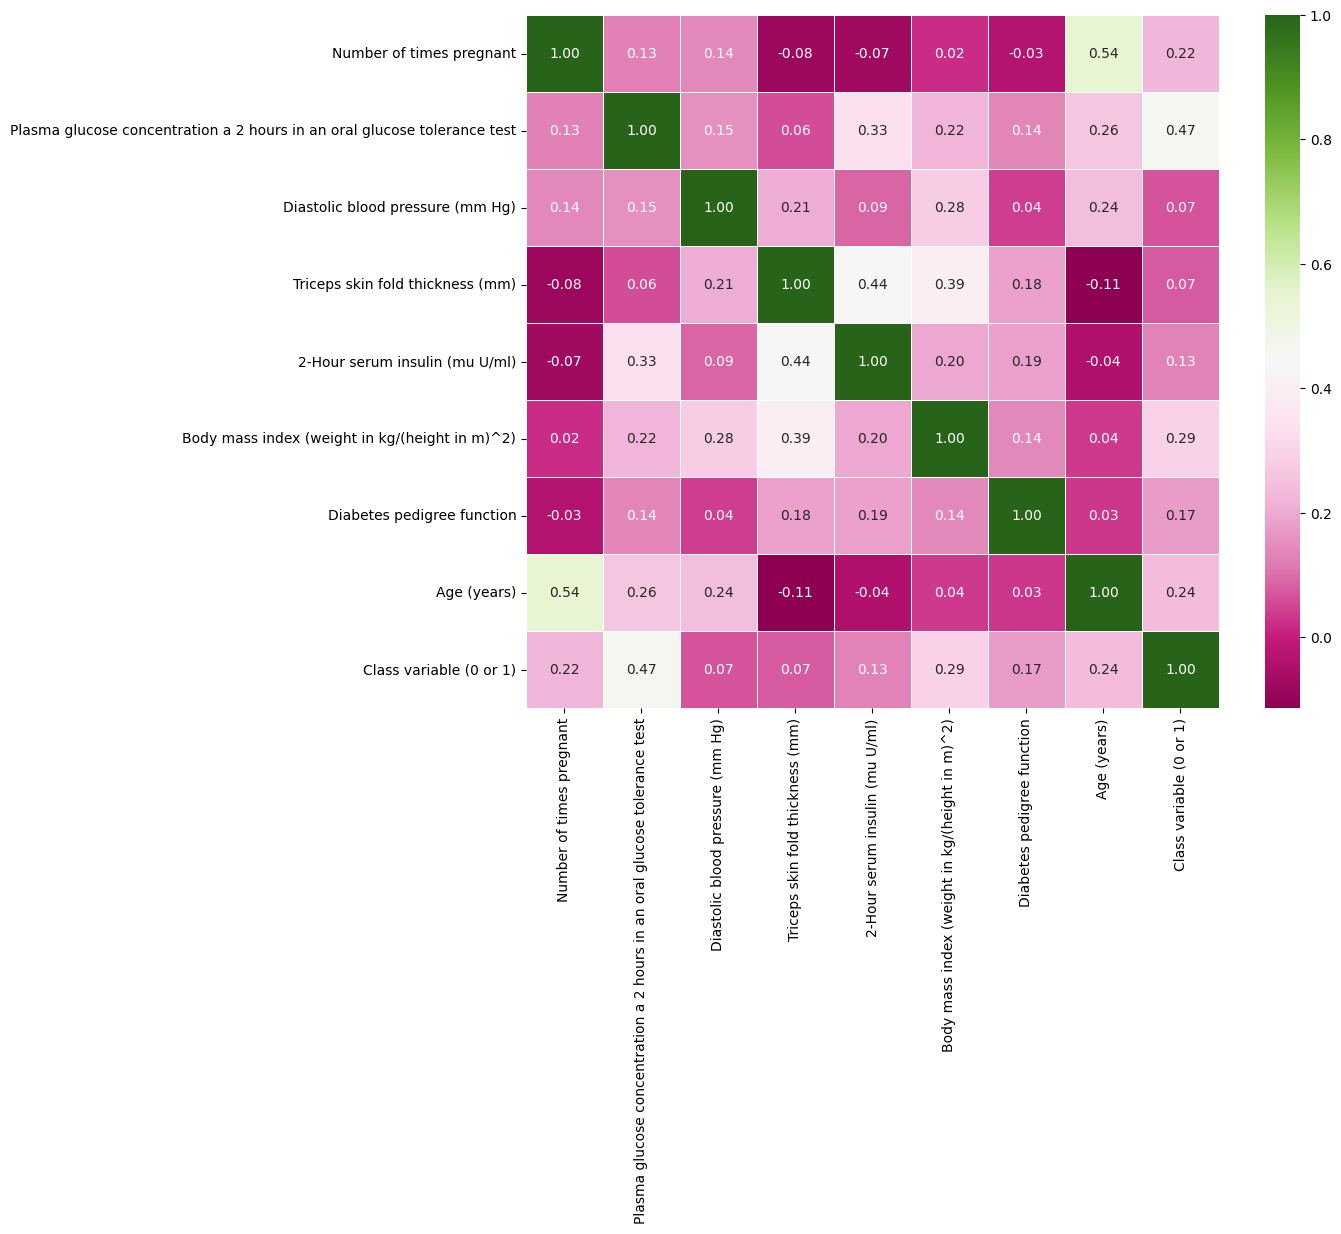

In [4]:
#смотрим корреляцию признаков
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt
plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr, annot=True, linewidths=.5, fmt='.2f',
            mask=np.zeros_like(corr, dtype=bool),
            cmap = sns.color_palette('PiYG', as_cmap=True), square=True)

In [5]:
#делим на тест и трейн
X = data.drop('Class variable (0 or 1)', axis=1)
y = data['Class variable (0 or 1)']
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [6]:
y.value_counts() #выборка не очень сбалансированная

Class variable (0 or 1)
0    500
1    268
Name: count, dtype: int64

In [7]:
#пайплайн
pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression())])

pipe.fit(X_train, y_train)
ypred_train = pipe.predict(X_train)
ypred_test = pipe.predict(X_test)
print(classification_report(ypred_train, y_train), classification_report(ypred_test, y_test))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84       419
           1       0.57      0.73      0.64       157

    accuracy                           0.78       576
   macro avg       0.73      0.76      0.74       576
weighted avg       0.80      0.78      0.78       576
               precision    recall  f1-score   support

           0       0.90      0.78      0.84       146
           1       0.52      0.74      0.61        46

    accuracy                           0.77       192
   macro avg       0.71      0.76      0.72       192
weighted avg       0.81      0.77      0.78       192



In [8]:
#уберем некоторые признаки, добавим параметр stratify и попробуем ещё раз
data.drop(['Diastolic blood pressure (mm Hg)', 'Triceps skin fold thickness (mm)', '2-Hour serum insulin (mu U/ml)', 'Diabetes pedigree function'], axis=1, inplace=True)

X = data.drop('Class variable (0 or 1)', axis=1)
y = data['Class variable (0 or 1)']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression())])

pipe.fit(X_train, y_train)
ypred_train = pipe.predict(X_train)
ypred_test = pipe.predict(X_test)
print(classification_report(ypred_train, y_train), classification_report(ypred_test, y_test))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83       417
           1       0.57      0.72      0.63       159

    accuracy                           0.77       576
   macro avg       0.72      0.75      0.73       576
weighted avg       0.79      0.77      0.78       576
               precision    recall  f1-score   support

           0       0.85      0.79      0.82       134
           1       0.58      0.67      0.62        58

    accuracy                           0.76       192
   macro avg       0.72      0.73      0.72       192
weighted avg       0.77      0.76      0.76       192



## Задача 2. 

Второй датасет - про покупателей велосипедов. 

In [25]:
data = pd.read_csv('bike_buyers_clean.csv')
data.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,No
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,No
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,No
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Yes
4,25597,Single,Male,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Yes


Пытаемся по характеристикам человека понять, купит он велик или нет. 

In [15]:
data.info() #пропущенных значений нет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                1000 non-null   int64 
 1   Marital Status    1000 non-null   object
 2   Gender            1000 non-null   object
 3   Income            1000 non-null   int64 
 4   Children          1000 non-null   int64 
 5   Education         1000 non-null   object
 6   Occupation        1000 non-null   object
 7   Home Owner        1000 non-null   object
 8   Cars              1000 non-null   int64 
 9   Commute Distance  1000 non-null   object
 10  Region            1000 non-null   object
 11  Age               1000 non-null   int64 
 12  Purchased Bike    1000 non-null   object
dtypes: int64(5), object(8)
memory usage: 101.7+ KB


In [26]:
data.drop(['ID'], axis=1, inplace=True)

In [27]:
data.Gender = data.Gender.apply(lambda x: 0 if x == 'Male' else 1)
data['Marital Status'] = data['Marital Status'].apply(lambda x: 0 if x == 'Single' else 1)
data['Home Owner'] = data['Home Owner'].apply(lambda x: 0 if x == 'No' else 1)
data['Purchased Bike'] = data['Purchased Bike'].apply(lambda x: 0 if x == 'No' else 1)

In [28]:
change_columns = ['Education', 'Occupation', 'Commute Distance', 'Region']
data[change_columns] = data[change_columns].apply(lambda x: pd.factorize(x)[0])

<Axes: >

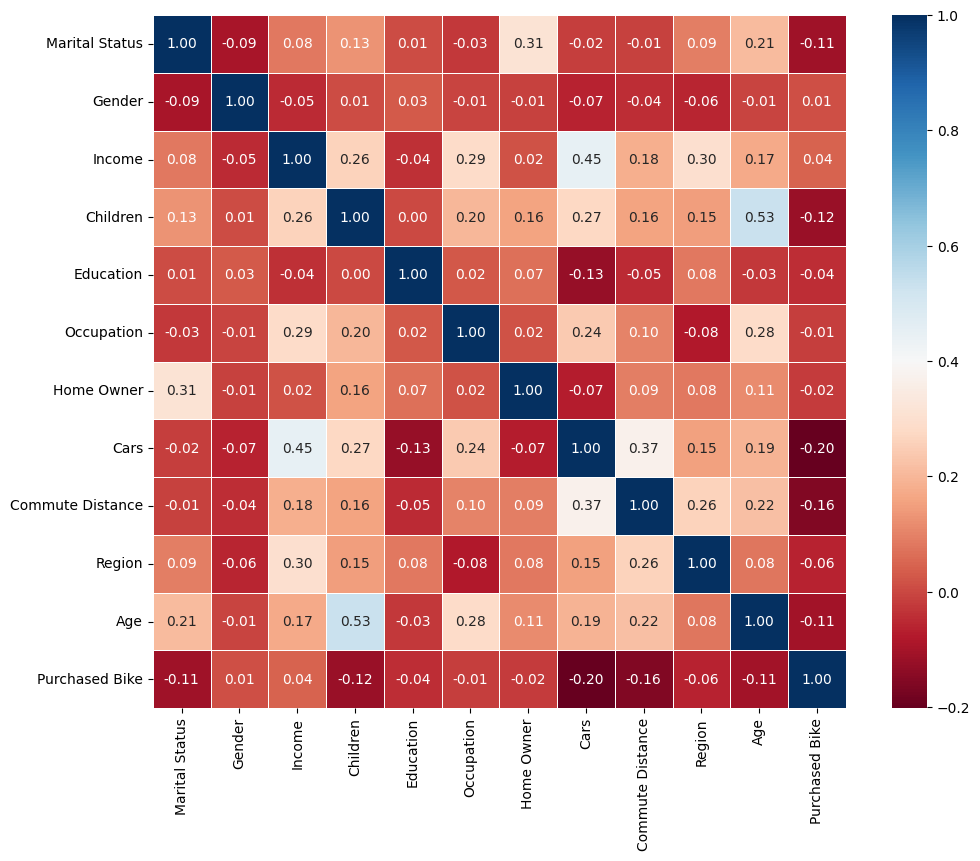

In [29]:
#смотрим корреляцию признаков
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt
plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr, annot=True, linewidths=.5, fmt='.2f',
            mask=np.zeros_like(corr, dtype=bool),
            cmap = sns.color_palette('RdBu', as_cmap=True), square=True)

In [30]:
#делим на тест и трейн
X = data.drop('Purchased Bike', axis=1) 
y = data['Purchased Bike']
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [31]:
y.value_counts() #выборка достаточно сбалансированная

Purchased Bike
0    519
1    481
Name: count, dtype: int64

In [32]:
#пайплайн
pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression())])

pipe.fit(X_train, y_train)
ypred_train = pipe.predict(X_train)
ypred_test = pipe.predict(X_test)
print(classification_report(ypred_train, y_train), classification_report(ypred_test, y_test))

              precision    recall  f1-score   support

           0       0.70      0.67      0.68       421
           1       0.60      0.63      0.61       329

    accuracy                           0.65       750
   macro avg       0.65      0.65      0.65       750
weighted avg       0.65      0.65      0.65       750
               precision    recall  f1-score   support

           0       0.75      0.57      0.65       154
           1       0.50      0.69      0.58        96

    accuracy                           0.62       250
   macro avg       0.62      0.63      0.61       250
weighted avg       0.65      0.62      0.62       250



In [33]:
#убираем некоторые признаки и пробуем еще раз
data.drop(['Occupation', 'Gender', 'Home Owner', 'Income'], axis=1, inplace=True)
X = data.drop('Purchased Bike', axis=1)
y = data['Purchased Bike']
X_train, X_test, y_train, y_test = train_test_split(X, y)

pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression())])

pipe.fit(X_train, y_train)
ypred_train = pipe.predict(X_train)
ypred_test = pipe.predict(X_test)
print(classification_report(ypred_train, y_train), classification_report(ypred_test, y_test))

              precision    recall  f1-score   support

           0       0.61      0.64      0.63       367
           1       0.64      0.62      0.63       383

    accuracy                           0.63       750
   macro avg       0.63      0.63      0.63       750
weighted avg       0.63      0.63      0.63       750
               precision    recall  f1-score   support

           0       0.54      0.62      0.58       120
           1       0.60      0.52      0.55       130

    accuracy                           0.57       250
   macro avg       0.57      0.57      0.57       250
weighted avg       0.57      0.57      0.57       250



In [34]:
#пробуем еще раз
data.drop(['Education', 'Age'], axis=1, inplace=True)
X = data.drop('Purchased Bike', axis=1)
y = data['Purchased Bike']
X_train, X_test, y_train, y_test = train_test_split(X, y)

pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression())])

pipe.fit(X_train, y_train)
ypred_train = pipe.predict(X_train)
ypred_test = pipe.predict(X_test)
print(classification_report(ypred_train, y_train), classification_report(ypred_test, y_test))


              precision    recall  f1-score   support

           0       0.66      0.62      0.64       426
           1       0.54      0.59      0.56       324

    accuracy                           0.61       750
   macro avg       0.60      0.60      0.60       750
weighted avg       0.61      0.61      0.61       750
               precision    recall  f1-score   support

           0       0.77      0.62      0.69       153
           1       0.54      0.71      0.62        97

    accuracy                           0.66       250
   macro avg       0.66      0.67      0.65       250
weighted avg       0.68      0.66      0.66       250

